## Task 1: Import and Inspect the Dataset

In [ ]:
dataset_path <- '/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv'

# Using tryCatch for robust file loading
df <- tryCatch({
  # Attempt to read the CSV file
  read.csv(dataset_path)
}, error = function(e) {
  # Handle specific error types if possible, or provide a general message
  if (grepl("cannot open file", e$message)) {
    message("Error: The file could not be opened. Check file path and permissions.")
  } else if (grepl("no such file or directory", e$message)) {
    message("Error: File not found. Please ensure the path is correct.")
  } else if (grepl("duplicate 'row.names' are not allowed", e$message)) {
    message("Error: Incorrect file format, possibly duplicate row names.")
  } else {
    message(paste("An unexpected error occurred while reading the file:", e$message))
  }
  return(NULL) # Return NULL to indicate failure
})

# Check if the dataframe was loaded successfully before proceeding
if (!is.null(df)) {
  message("Dataset loaded successfully!")
} else {
  message("Failed to load dataset. Please check the error message above.")
}

Dataset loaded successfully!



### 1. Display the first six records

In [ ]:
if (!is.null(df)) {
  print(head(df))
}

  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin


### 2. Display the structure of the dataset

In [ ]:
if (!is.null(df)) {
  print(str(df))
}

'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" ...
NULL


### 3. Display the number of rows and columns

In [ ]:
if (!is.null(df)) {
  cat("Number of rows: ", nrow(df), "\n")
  cat("Number of columns: ", ncol(df), "\n")
}

Number of rows:  35064 
Number of columns:  18 


### 4. Check whether the dataset contains missing values

In [ ]:
if (!is.null(df)) {
  if (any(is.na(df))) {
    cat("The dataset contains missing values.\n")
  } else {
    cat("The dataset does not contain missing values.\n")
  }
}

The dataset contains missing values.


### 5. Display the total number of missing values

In [ ]:
if (!is.null(df)) {
  cat("Total number of missing values: ", sum(is.na(df)), "\n")
}

Total number of missing values:  7271 


## Task 2: Understand NA, NULL, and NaN

### 1. `NA` (Not Available)

Represents an unavailable or missing observation in a vector, factor, or data frame. `NA` is a logical constant of length 1, but it can be coerced to other types (e.g., `NA_integer_`, `NA_real_`, `NA_character_`).

In [ ]:
# Example of NA in a numeric vector
temperature <- c(28, 30, NA, 32, 29)
cat("Vector with NA: ", temperature, "\n")
cat("Is 3rd element NA? ", is.na(temperature[3]), "\n")
cat("Which elements are NA? ", which(is.na(temperature)), "\n")

# Example of NA in a character vector
names <- c("Alice", "Bob", NA, "Charlie")
cat("Character vector with NA: ", paste(names, collapse = ", "), "\n")
cat("Is 3rd element NA? ", is.na(names[3]), "\n")

Vector with NA:  28 30 NA 32 29 
Is 3rd element NA?  TRUE 
Which elements are NA?  3 
Character vector with NA:  Alice, Bob, NA, Charlie 
Is 3rd element NA?  TRUE 


### 2. `NULL`

Represents an absent or empty R object. It is often used to indicate the absence of a value or an empty list. `NULL` has no type or length.

In [ ]:
# Example of NULL
missing_object <- NULL
cat("Value of missing_object: ", as.character(missing_object), "\n")
cat("Is missing_object NULL? ", is.null(missing_object), "\n")
cat("Length of missing_object: ", length(missing_object), "\n")

# NULL vs NA: NULL cannot be part of a vector, NA can.
# This will result in an error if uncommented: c(1, NULL, 3)

empty_list <- list()
cat("Is empty_list NULL? ", is.null(empty_list), "\n")
# Note: An empty list is not NULL, though it is empty.

Value of missing_object:   
Is missing_object NULL?  TRUE 
Length of missing_object:  0 
Is empty_list NULL?  FALSE 


### 3. `NaN` (Not a Number)

Represents an undefined numerical result, typically from mathematical operations that produce indeterminate forms (e.g., `0/0`, `Inf - Inf`). `NaN` is a special type of `NA` in R, meaning `is.na(NaN)` will return `TRUE`.

In [ ]:
# Example of NaN
undefined_value <- 0 / 0
cat("Result of 0/0: ", undefined_value, "\n")
cat("Is undefined_value NaN? ", is.nan(undefined_value), "\n")
cat("Is undefined_value NA? ", is.na(undefined_value), "\n")

# Another example: infinity minus infinity
inf_minus_inf <- Inf - Inf
cat("Result of Inf - Inf: ", inf_minus_inf, "\n")
cat("Is inf_minus_inf NaN? ", is.nan(inf_minus_inf), "\n")

# NaN in a vector
numeric_vector_with_nan <- c(10, 20, NaN, 30)
cat("Numeric vector with NaN: ", numeric_vector_with_nan, "\n")
cat("Which elements are NaN? ", which(is.nan(numeric_vector_with_nan)), "\n")
cat("Which elements are NA (including NaN)? ", which(is.na(numeric_vector_with_nan)), "\n")

Result of 0/0:  NaN 
Is undefined_value NaN?  TRUE 
Is undefined_value NA?  TRUE 
Result of Inf - Inf:  NaN 
Is inf_minus_inf NaN?  TRUE 
Numeric vector with NaN:  10 20 NaN 30 
Which elements are NaN?  3 
Which elements are NA (including NaN)?  3 


## Task 3: Create a Missing-Value Summary Function

In [ ]:
# Define the missing_summary function
missing_summary <- function(df, variables) {
  # Initialize an empty data frame to store the summary
  summary_df <- data.frame(
    Variable = character(),
    TotalRecords = integer(),
    MissingValues = integer(),
    MissingPercentage = numeric(),
    stringsAsFactors = FALSE
  )

  # Get total number of rows in the dataframe
  total_rows <- nrow(df)

  # Loop through each specified variable
  for (var in variables) {
    if (var %in% names(df)) {
      # Calculate missing values
      missing_count <- sum(is.na(df[[var]]))

      # Calculate missing percentage
      missing_percent <- (missing_count / total_rows) * 100

      # Add row to summary data frame
      summary_df <- rbind(summary_df, data.frame(
        Variable = var,
        TotalRecords = total_rows,
        MissingValues = missing_count,
        MissingPercentage = round(missing_percent, 2),
        stringsAsFactors = FALSE
      ))

      # Check for warning condition
      if (missing_percent > 20) {
        warning(paste0("Variable '", var, "' has more than 20% missing values (", round(missing_percent, 2), "%)."))
      }
    } else {
      warning(paste0("Variable '", var, "' not found in the data frame."))
    }
  }

  return(summary_df)
}

# Define the selected variables for the summary
selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

# Apply the function to the dataset
if (!is.null(df)) {
  missing_values_table <- missing_summary(df, selected_variables)
  print(missing_values_table)
}

  Variable TotalRecords MissingValues MissingPercentage
1    PM2.5        35064           925              2.64
2     PM10        35064           718              2.05
3      SO2        35064           935              2.67
4      NO2        35064          1023              2.92
5     TEMP        35064            20              0.06
6     WSPM        35064            14              0.04
7       wd        35064            81              0.23


## Task 4: Identify Invalid Numerical Results

In [ ]:
if (!is.null(df)) {
  # Create the new variable pollution_ratio
  # Using suppressWarnings to avoid warnings about NaNs from 0/0 or Inf/Inf when creating the ratio
  df$pollution_ratio <- suppressWarnings(df$PM2.5 / df$PM10)

  cat("### Checking pollution_ratio for NA, NaN, and Infinite values\n")

  # Check for NA values
  na_count <- sum(is.na(df$pollution_ratio))
  cat("Number of NA values in pollution_ratio: ", na_count, "\n")

  # Check for NaN values
  nan_count <- sum(is.nan(df$pollution_ratio))
  cat("Number of NaN values in pollution_ratio: ", nan_count, "\n")

  # Check for positive and negative infinity
  inf_count <- sum(is.infinite(df$pollution_ratio))
  pos_inf_count <- sum(is.infinite(df$pollution_ratio) & df$pollution_ratio > 0)
  neg_inf_count <- sum(is.infinite(df$pollution_ratio) & df$pollution_ratio < 0)
  cat("Number of Infinite values in pollution_ratio: ", inf_count, "\n")
  cat("  (Positive Infinity: ", pos_inf_count, ", Negative Infinity: ", neg_inf_count, ")\n")

  # Replace all NaN and infinite values in pollution_ratio with NA
  # is.nan(x) is TRUE only for NaN. is.infinite(x) is TRUE for Inf and -Inf.
  # is.na(x) is TRUE for NA and NaN. So, to specifically target NaN and Inf,
  # we use is.nan and is.infinite separately.
  df$pollution_ratio[is.nan(df$pollution_ratio)] <- NA
  df$pollution_ratio[is.infinite(df$pollution_ratio)] <- NA

  cat("\n### After replacing NaN and Infinite values with NA:\n")

  # Re-check counts after replacement
  nan_count_after <- sum(is.nan(df$pollution_ratio))
  inf_count_after <- sum(is.infinite(df$pollution_ratio))
  na_count_after <- sum(is.na(df$pollution_ratio))

  cat("Number of NaN values in pollution_ratio (after replacement): ", nan_count_after, "\n")
  cat("Number of Infinite values in pollution_ratio (after replacement): ", inf_count_after, "\n")
  cat("Total NA values in pollution_ratio (after replacement, including original NAs): ", na_count_after, "\n")

  # Display a few records to confirm changes
  cat("\nHead of dataframe with new pollution_ratio column:\n")
  print(head(df[, c("PM2.5", "PM10", "pollution_ratio")]))
}

### Checking pollution_ratio for NA, NaN, and Infinite values
Number of NA values in pollution_ratio:  934 
Number of NaN values in pollution_ratio:  0 
Number of Infinite values in pollution_ratio:  0 
  (Positive Infinity:  0 , Negative Infinity:  0 )

### After replacing NaN and Infinite values with NA:
Number of NaN values in pollution_ratio (after replacement):  0 
Number of Infinite values in pollution_ratio (after replacement):  0 
Total NA values in pollution_ratio (after replacement, including original NAs):  934 

Head of dataframe with new pollution_ratio column:
  PM2.5 PM10 pollution_ratio
1     4    4               1
2     8    8               1
3     7    7               1
4     6    6               1
5     3    3               1
6     5    5               1


## Task 5: Handle Missing Numerical Values Using a Loop

In [ ]:
if (!is.null(df)) {
  # Create a vector containing the names of selected numerical variables
  numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

  cat("### Handling Missing Numerical Values using Median Imputation\n\n")

  # Use a for loop to perform the operations for every variable
  for (var_name in numeric_variables) {
    cat(paste0("Processing variable: ", var_name, "\n"))

    # 1. Check whether the column exists.
    if (!(var_name %in% names(df))) {
      warning(paste0("Column '", var_name, "' does not exist in the dataframe. Skipping.\n"))
      next # Skip to the next variable in the loop
    }

    # Ensure the column is numeric before proceeding with median imputation
    if (!is.numeric(df[[var_name]])) {
      warning(paste0("Column '", var_name, "' is not numeric. Skipping median imputation.\n"))
      next
    }

    # 2. Count the missing values before treatment
    missing_before <- sum(is.na(df[[var_name]]))
    cat(paste0("  Number of missing values before treatment: ", missing_before, "\n"))

    if (missing_before > 0) {
      # 3. Calculate the median using: median(variable, na.rm = TRUE)
      # Using tryCatch to handle cases where median cannot be calculated (e.g., all NAs)
      median_value <- tryCatch({
        median(df[[var_name]], na.rm = TRUE)
      }, error = function(e) {
        warning(paste0("  Could not calculate median for '", var_name, "': ", e$message, ". Skipping imputation.\n"))
        return(NA) # Return NA if median cannot be calculated
      })

      if (!is.na(median_value)) {
        cat(paste0("  Median used for replacement: ", round(median_value, 2), "\n"))

        # 4. Replace missing values with the median
        df[[var_name]][is.na(df[[var_name]])] <- median_value

        # 5. Display number of missing values after treatment
        missing_after <- sum(is.na(df[[var_name]]))
        cat(paste0("  Number of missing values after treatment: ", missing_after, "\n\n"))
      } else {
        cat("  Median calculation failed or returned NA. No replacement performed.\n\n")
      }
    } else {
      cat("  No missing values found. No replacement needed.\n\n")
    }
  }
  cat("### Numerical missing value handling complete.\n")
} else {
  message("Dataframe 'df' is NULL. Cannot perform missing value handling.")
}

### Handling Missing Numerical Values using Median Imputation

Processing variable: PM2.5
  Number of missing values before treatment: 925
  Median used for replacement: 58
  Number of missing values after treatment: 0

Processing variable: PM10
  Number of missing values before treatment: 718
  Median used for replacement: 87
  Number of missing values after treatment: 0

Processing variable: SO2
  Number of missing values before treatment: 935
  Median used for replacement: 9
  Number of missing values after treatment: 0

Processing variable: NO2
  Number of missing values before treatment: 1023
  Median used for replacement: 53
  Number of missing values after treatment: 0

Processing variable: TEMP
  Number of missing values before treatment: 20
  Median used for replacement: 14.5
  Number of missing values after treatment: 0

Processing variable: WSPM
  Number of missing values before treatment: 14
  Median used for replacement: 1.4
  Number of missing values after treatment: 0

#

## Task 6: Handle Missing Categorical Values

In [ ]:
# Create a function named calculate_mode()
calculate_mode <- function(x) {
  # Remove NA values before calculating mode
  x <- x[!is.na(x)]

  # Check if there are any non-NA values left
  if (length(x) == 0) {
    warning("Cannot calculate mode for a vector with only NA values or an empty vector.")
    return(NA)
  }

  # Calculate the frequency of each unique value
  freq <- table(x)

  # Get the names of the most frequent values (modes)
  modes <- names(freq)[freq == max(freq)]

  # If there are multiple modes, return the first one for simplicity, or handle as needed
  if (length(modes) > 1) {
    warning("Multiple modes found. Returning the first one.")
    return(modes[1])
  } else {
    return(modes)
  }
}

# Ensure df is not NULL before proceeding
if (!is.null(df)) {
  # 1. Calculate the mode of wd
  cat("### Handling Missing Values in 'wd' (Wind Direction)\n")

  # Count missing values before replacement
  missing_before_wd <- sum(is.na(df$wd))
  cat(paste0("Number of missing values in 'wd' before replacement: ", missing_before_wd, "\n"))

  if (missing_before_wd > 0) {
    mode_wd <- calculate_mode(df$wd)

    if (!is.na(mode_wd)) {
      cat(paste0("Calculated mode for 'wd': ", mode_wd, "\n"))

      # 2. Replace missing values in wd with the mode
      df$wd[is.na(df$wd)] <- mode_wd

      # 3. Display the number of missing values after replacement
      missing_after_wd <- sum(is.na(df$wd))
      cat(paste0("Number of missing values in 'wd' after replacement: ", missing_after_wd, "\n"))
    } else {
      cat("Mode could not be calculated for 'wd'. No replacement performed.\n")
    }
  } else {
    cat("No missing values found in 'wd'. No replacement needed.\n")
  }
  cat("### Categorical missing value handling complete for 'wd'.\n")
} else {
  message("Dataframe 'df' is NULL. Cannot perform missing value handling for 'wd'.")
}

### Handling Missing Values in 'wd' (Wind Direction)
Number of missing values in 'wd' before replacement: 81
Calculated mode for 'wd': NE
Number of missing values in 'wd' after replacement: 0
### Categorical missing value handling complete for 'wd'.


## Task 7: Implement Error Handling

In [ ]:
# Create a reusable function named clean_variable()
clean_variable <- function(data, var_name) {
  # Use tryCatch to handle potential errors
  result <- tryCatch({
    # 1. Check whether the variable exists
    if (!(var_name %in% names(data))) {
      stop(paste0("Error: Variable '", var_name, "' does not exist in the dataset."))
    }

    # 2. Check whether the variable is numerical
    if (!is.numeric(data[[var_name]])) {
      stop(paste0("Error: Variable '", var_name, "' is not numerical. Cannot calculate median."))
    }

    # Get the column vector
    var_vector <- data[[var_name]]

    # Check if the variable contains only missing values
    if (all(is.na(var_vector))) {
      stop(paste0("Error: Variable '", var_name, "' contains only missing values. Median cannot be calculated."))
    }

    # Calculate the median, handling potential errors if median cannot be calculated
    median_value <- tryCatch({
      median(var_vector, na.rm = TRUE)
    }, error = function(e) {
      stop(paste0("Error: Median could not be calculated for '", var_name, "': ", e$message))
    })

    # Replace missing values using the median
    data[[var_name]][is.na(var_vector)] <- median_value

    message(paste0("Variable '", var_name, "' cleaned successfully. Missing values imputed with median: ", round(median_value, 2)))

    # Return the cleaned data frame (or just the cleaned variable if preferred, but for this context, returning the modified df is more practical)
    return(data[[var_name]])

  }, error = function(e) {
    # Display an informative message for caught errors
    message(e$message)
    return(NULL) # Return NULL to indicate failure
  })

  return(result)
}

# --- Demonstration of clean_variable function ---
if (!is.null(df)) {
  cat("\n### Demonstrating `clean_variable()` with different scenarios:\n\n")

  # Scenario 1: Clean an existing numerical variable with missing values (e.g., PM2.5)
  cat("Scenario 1: Cleaning 'PM2.5' (numerical, with NAs)\n")
  df_cleaned_pm25 <- df # Create a copy to show individual changes
  original_pm25_na_count <- sum(is.na(df_cleaned_pm25$PM2.5))
  cat(paste0("  PM2.5 NA count before: ", original_pm25_na_count, "\n"))
  df_cleaned_pm25$PM2.5 <- clean_variable(df_cleaned_pm25, "PM2.5")
  if (!is.null(df_cleaned_pm25$PM2.5)) {
      cat(paste0("  PM2.5 NA count after: ", sum(is.na(df_cleaned_pm25$PM2.5)), "\n\n"))
  }

  # Scenario 2: Variable does not exist
  cat("Scenario 2: Trying to clean a non-existent variable ('NonExistentVar')\n")
  clean_variable(df, "NonExistentVar")
  cat("\n")

  # Scenario 3: Categorical variable passed instead of a numerical variable ('wd')
  cat("Scenario 3: Trying to clean a categorical variable ('wd')\n")
  clean_variable(df, "wd")
  cat("\n")

  # Scenario 4: Variable contains only missing values (create a dummy one for demonstration)
  cat("Scenario 4: Trying to clean a variable with only missing values ('AllNAVar')\n")
  df_temp <- df # Create a temporary df for this scenario
  df_temp$AllNAVar <- rep(NA, nrow(df_temp))
  clean_variable(df_temp, "AllNAVar")
  cat("\n")

  # Scenario 5: Cleaning another numerical variable (e.g., TEMP)
  cat("Scenario 5: Cleaning 'TEMP' (numerical, with NAs)\n")
  df_cleaned_temp <- df # Create a copy to show individual changes
  original_temp_na_count <- sum(is.na(df_cleaned_temp$TEMP))
  cat(paste0("  TEMP NA count before: ", original_temp_na_count, "\n"))
  df_cleaned_temp$TEMP <- clean_variable(df_cleaned_temp, "TEMP")
  if (!is.null(df_cleaned_temp$TEMP)) {
      cat(paste0("  TEMP NA count after: ", sum(is.na(df_cleaned_temp$TEMP)), "\n\n"))
  }

} else {
  message("Dataframe 'df' is NULL. Cannot perform error handling demonstration.")
}


### Demonstrating `clean_variable()` with different scenarios:

Scenario 1: Cleaning 'PM2.5' (numerical, with NAs)
  PM2.5 NA count before: 0


Variable 'PM2.5' cleaned successfully. Missing values imputed with median: 58



  PM2.5 NA count after: 0

Scenario 2: Trying to clean a non-existent variable ('NonExistentVar')


Error: Variable 'NonExistentVar' does not exist in the dataset.




Scenario 3: Trying to clean a categorical variable ('wd')


...


Scenario 4: Trying to clean a variable with only missing values ('AllNAVar')


Error: Variable 'AllNAVar' is not numerical. Cannot calculate median.




Scenario 5: Cleaning 'TEMP' (numerical, with NAs)
  TEMP NA count before: 0


Variable 'TEMP' cleaned successfully. Missing values imputed with median: 14.5



  TEMP NA count after: 0



## Task 8: Compare Missing Values Before and After Cleaning

In [ ]:

# Re-define the selected variables for comparison
comparison_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

cat("### Preparing Comparison Table\n")

df_initial <- read.csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv')

# Get missing summary 'Before Cleaning'
missing_before_df <- missing_summary(df_initial, comparison_variables)
names(missing_before_df)[names(missing_before_df) == "MissingValues"] <- "MissingBefore"


df_cleaned_for_comparison <- read.csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv')

# Task 4 re-application (pollution_ratio)
df_cleaned_for_comparison$pollution_ratio <- suppressWarnings(df_cleaned_for_comparison$PM2.5 / df_cleaned_for_comparison$PM10)
df_cleaned_for_comparison$pollution_ratio[is.nan(df_cleaned_for_comparison$pollution_ratio)] <- NA
df_cleaned_for_comparison$pollution_ratio[is.infinite(df_cleaned_for_comparison$pollution_ratio)] <- NA

# Task 5 re-application (numeric variables)
numeric_variables_for_cleaning <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")
for (var_name in numeric_variables_for_cleaning) {
  if (var_name %in% names(df_cleaned_for_comparison) && is.numeric(df_cleaned_for_comparison[[var_name]])) {
    missing_before_var <- sum(is.na(df_cleaned_for_comparison[[var_name]]))
    if (missing_before_var > 0) {
      median_value <- tryCatch({ median(df_cleaned_for_comparison[[var_name]], na.rm = TRUE) }, error = function(e) NA)
      if (!is.na(median_value)) {
        df_cleaned_for_comparison[[var_name]][is.na(df_cleaned_for_comparison[[var_name]])] <- median_value
      }
    }
  }
}

# Task 6 re-application (categorical 'wd')
if ("wd" %in% names(df_cleaned_for_comparison)) {
  missing_before_wd_cleaned <- sum(is.na(df_cleaned_for_comparison$wd))
  if (missing_before_wd_cleaned > 0) {
    mode_wd <- calculate_mode(df_cleaned_for_comparison$wd)
    if (!is.na(mode_wd)) {
      df_cleaned_for_comparison$wd[is.na(df_cleaned_for_comparison$wd)] <- mode_wd
    }
  }
}
# --- End of re-application of cleaning steps ---

# Get missing summary 'After Cleaning'
missing_after_df <- missing_summary(df_cleaned_for_comparison, comparison_variables)
names(missing_after_df)[names(missing_after_df) == "MissingValues"] <- "MissingAfter"

# Merge the two summaries for comparison
comparison_table <- merge(missing_before_df[, c("Variable", "MissingBefore")],
                          missing_after_df[, c("Variable", "MissingAfter")],
                          by = "Variable", all = TRUE)

# Calculate 'Values Replaced'
comparison_table$ValuesReplaced <- comparison_table$MissingBefore - comparison_table$MissingAfter

# Display the comparison table
print(comparison_table)

cat("\n### Interpretation:\n")
# Interpret whether all selected missing values have been handled successfully.
if (all(comparison_table$MissingAfter == 0)) {
  cat("All selected variables (PM2.5, PM10, SO2, NO2, TEMP, WSPM, wd) have had their missing values successfully imputed. The 'Missing After' column shows 0 for all these variables.")
} else {
  cat("Some selected variables still contain missing values after the cleaning process. Please review the 'Missing After' column for details.")
}


### Preparing Comparison Table
  Variable MissingBefore MissingAfter ValuesReplaced
1      NO2          1023            0           1023
2     PM10           718            0            718
3    PM2.5           925            0            925
4      SO2           935            0            935
5     TEMP            20            0             20
6       wd            81            0             81
7     WSPM            14            0             14

### Interpretation:
All selected variables (PM2.5, PM10, SO2, NO2, TEMP, WSPM, wd) have had their missing values successfully imputed. The 'Missing After' column shows 0 for all these variables.

## Task 9: Generate One Visualization

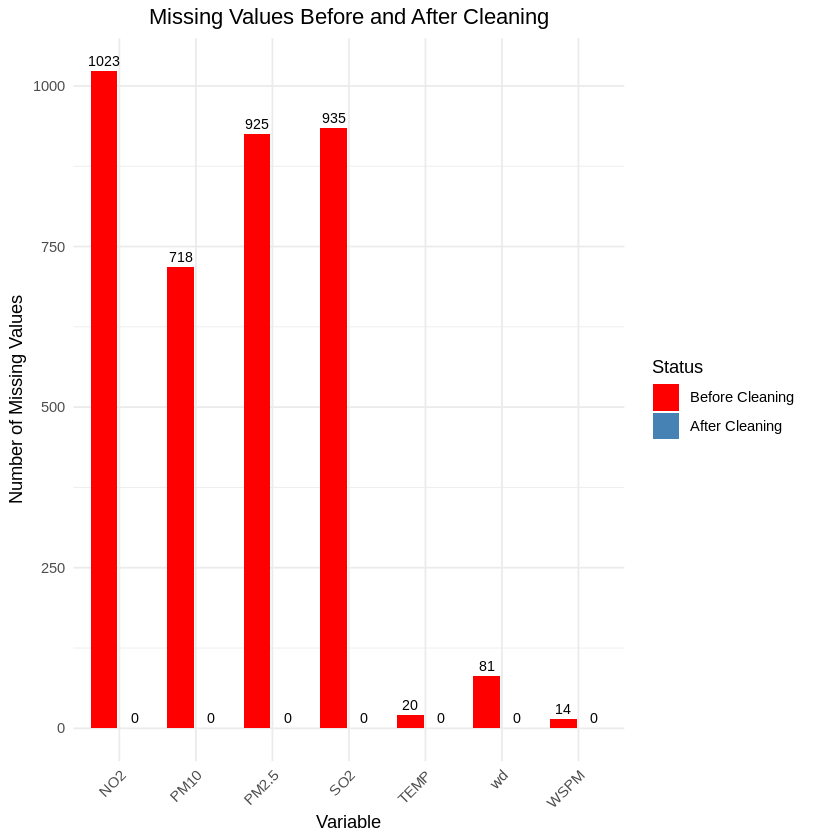

In [ ]:
if (!require(ggplot2)) {
  install.packages("ggplot2")
  library(ggplot2)
}
if (!require(reshape2)) {
  install.packages("reshape2")
  library(reshape2)
}

# Re-define the selected variables for comparison
comparison_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

df_initial <- read.csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv')

# Get missing summary 'Before Cleaning'
missing_before_df <- missing_summary(df_initial, comparison_variables)
names(missing_before_df)[names(missing_before_df) == "MissingValues"] <- "MissingBefore"

df_cleaned_for_comparison_plot <- read.csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv')

# Task 4 re-application (pollution_ratio) if necessary, though not directly plotted here
df_cleaned_for_comparison_plot$pollution_ratio <- suppressWarnings(df_cleaned_for_comparison_plot$PM2.5 / df_cleaned_for_comparison_plot$PM10)
df_cleaned_for_comparison_plot$pollution_ratio[is.nan(df_cleaned_for_comparison_plot$pollution_ratio)] <- NA
df_cleaned_for_comparison_plot$pollution_ratio[is.infinite(df_cleaned_for_comparison_plot$pollution_ratio)] <- NA

# Task 5 re-application (numeric variables)
numeric_variables_for_cleaning <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")
for (var_name in numeric_variables_for_cleaning) {
  if (var_name %in% names(df_cleaned_for_comparison_plot) && is.numeric(df_cleaned_for_comparison_plot[[var_name]])) {
    missing_before_var <- sum(is.na(df_cleaned_for_comparison_plot[[var_name]]))
    if (missing_before_var > 0) {
      median_value <- tryCatch({ median(df_cleaned_for_comparison_plot[[var_name]], na.rm = TRUE) }, error = function(e) NA)
      if (!is.na(median_value)) {
        df_cleaned_for_comparison_plot[[var_name]][is.na(df_cleaned_for_comparison_plot[[var_name]])] <- median_value
      }
    }
  }
}

# Task 6 re-application (categorical 'wd')
if ("wd" %in% names(df_cleaned_for_comparison_plot)) {
  missing_before_wd_cleaned <- sum(is.na(df_cleaned_for_comparison_plot$wd))
  if (missing_before_wd_cleaned > 0) {
    mode_wd <- calculate_mode(df_cleaned_for_comparison_plot$wd)
    if (!is.na(mode_wd)) {
      df_cleaned_for_comparison_plot$wd[is.na(df_cleaned_for_comparison_plot$wd)] <- mode_wd
    }
  }
}

# Get missing summary 'After Cleaning'
missing_after_df <- missing_summary(df_cleaned_for_comparison_plot, comparison_variables)
names(missing_after_df)[names(missing_after_df) == "MissingValues"] <- "MissingAfter"

# Merge the two summaries for comparison
comparison_table_plot <- merge(missing_before_df[, c("Variable", "MissingBefore")],
                               missing_after_df[, c("Variable", "MissingAfter")],
                               by = "Variable", all = TRUE)
# --- Regenerate comparison_table for plot ---END

# Reshape data for ggplot2 (long format)
data_long <- melt(comparison_table_plot, id.vars = "Variable", variable.name = "Type", value.name = "MissingCount")

# Create the bar chart
if (!is.null(df)) {
  ggplot(data_long, aes(x = Variable, y = MissingCount, fill = Type)) +
    geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
    geom_text(aes(label = MissingCount), # Add text labels
              position = position_dodge(width = 0.8),
              vjust = -0.5, # Adjust vertical position
              size = 3) + # Adjust text size
    labs(
      title = "Missing Values Before and After Cleaning",
      x = "Variable",
      y = "Number of Missing Values",
      fill = "Status"
    ) +
    scale_fill_manual(values = c("MissingBefore" = "red", "MissingAfter" = "steelblue"),
                      labels = c("MissingBefore" = "Before Cleaning", "MissingAfter" = "After Cleaning")) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          plot.title = element_text(hjust = 0.5))
} else {
  message("Dataframe 'df' is NULL. Cannot generate visualization.")
}

## Task 10: Export the Cleaned Dataset

In [ ]:
if (!is.null(df)) {
  output_file_path <- "cleaned_air_quality_data.csv"

  write.csv(df, output_file_path, row.names = FALSE)

  cat(paste0("Cleaned dataset exported successfully to: ", output_file_path, "\n"))
}

Cleaned dataset exported successfully to: cleaned_air_quality_data.csv
